In [27]:
# Import libraries
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands

In [2]:
# Load dataset, re-format date
df = pd.read_csv("../data/processed/master_dataset.csv",parse_dates=["date"])
df = df.set_index("date").sort_index()

df.head()

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions
date,,,,,,,,
2020-01-01,7195.24,7255.0,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0
2020-01-02,7200.77,7212.5,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0
2020-01-03,6965.49,7405.0,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0
2020-01-04,7345.00,7404.0,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0
2020-01-05,7354.19,7495.0,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0


In [5]:
# Target
df["target"] = df["close"].shift(-1)
df[["close", "target"]].head()

,close,target
date,,
2020-01-01,7200.85,6965.71
2020-01-02,6965.71,7344.96
2020-01-03,7344.96,7354.11
2020-01-04,7354.11,7358.75
2020-01-05,7358.75,7758.00


In [45]:
# Close price scale based on period
for lag in [1, 2, 3, 7, 14, 30]:
    df[f"close_lag_{lag}"] = df["close"].shift(lag)

df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,bb_width,day_of_week,day_of_month,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,2,1,1,1,0,0.974928,-0.222521,0.5,0.866025
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,3,2,1,1,0,0.433884,-0.900969,0.5,0.866025
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,4,3,1,1,0,-0.433884,-0.900969,0.5,0.866025
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,NaN,5,4,1,1,1,-0.974928,-0.222521,0.5,0.866025
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,NaN,6,5,1,1,1,-0.781831,0.623490,0.5,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,0.075644,6,3,5,2,1,-0.781831,0.623490,0.5,-0.866025
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,0.075731,0,4,5,2,0,0.000000,1.000000,0.5,-0.866025
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,0.081457,1,5,5,2,0,0.781831,0.623490,0.5,-0.866025


In [44]:
# Features based on period
features_to_lag = ["volume", "fear_greed", "hash_rate", "n_transactions"]
lags = [1, 3, 7]

for feat in features_to_lag:
    for lag in lags:
        df[f"{feat}_lag_{lag}"] = df[feat].shift(lag)

df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,bb_width,day_of_week,day_of_month,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,2,1,1,1,0,0.974928,-0.222521,0.5,0.866025
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,3,2,1,1,0,0.433884,-0.900969,0.5,0.866025
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,4,3,1,1,0,-0.433884,-0.900969,0.5,0.866025
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,NaN,5,4,1,1,1,-0.974928,-0.222521,0.5,0.866025
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,NaN,6,5,1,1,1,-0.781831,0.623490,0.5,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,0.075644,6,3,5,2,1,-0.781831,0.623490,0.5,-0.866025
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,0.075731,0,4,5,2,0,0.000000,1.000000,0.5,-0.866025
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,0.081457,1,5,5,2,0,0.781831,0.623490,0.5,-0.866025


In [43]:
# Daily, weekly, monthly returns (% change)
df["return_1d"] = df["close"].pct_change(1)
df["return_7d"] = df["close"].pct_change(7)
df["return_30d"] = df["close"].pct_change(30)

# Lag the returns (so model can use yesterday's return to predict today)
df["return_1d_lag_1"] = df["return_1d"].shift(1)
df["return_7d_lag_1"] = df["return_7d"].shift(1)

df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,bb_width,day_of_week,day_of_month,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,2,1,1,1,0,0.974928,-0.222521,0.5,0.866025
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,3,2,1,1,0,0.433884,-0.900969,0.5,0.866025
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,4,3,1,1,0,-0.433884,-0.900969,0.5,0.866025
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,NaN,5,4,1,1,1,-0.974928,-0.222521,0.5,0.866025
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,NaN,6,5,1,1,1,-0.781831,0.623490,0.5,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,0.075644,6,3,5,2,1,-0.781831,0.623490,0.5,-0.866025
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,0.075731,0,4,5,2,0,0.000000,1.000000,0.5,-0.866025
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,0.081457,1,5,5,2,0,0.781831,0.623490,0.5,-0.866025


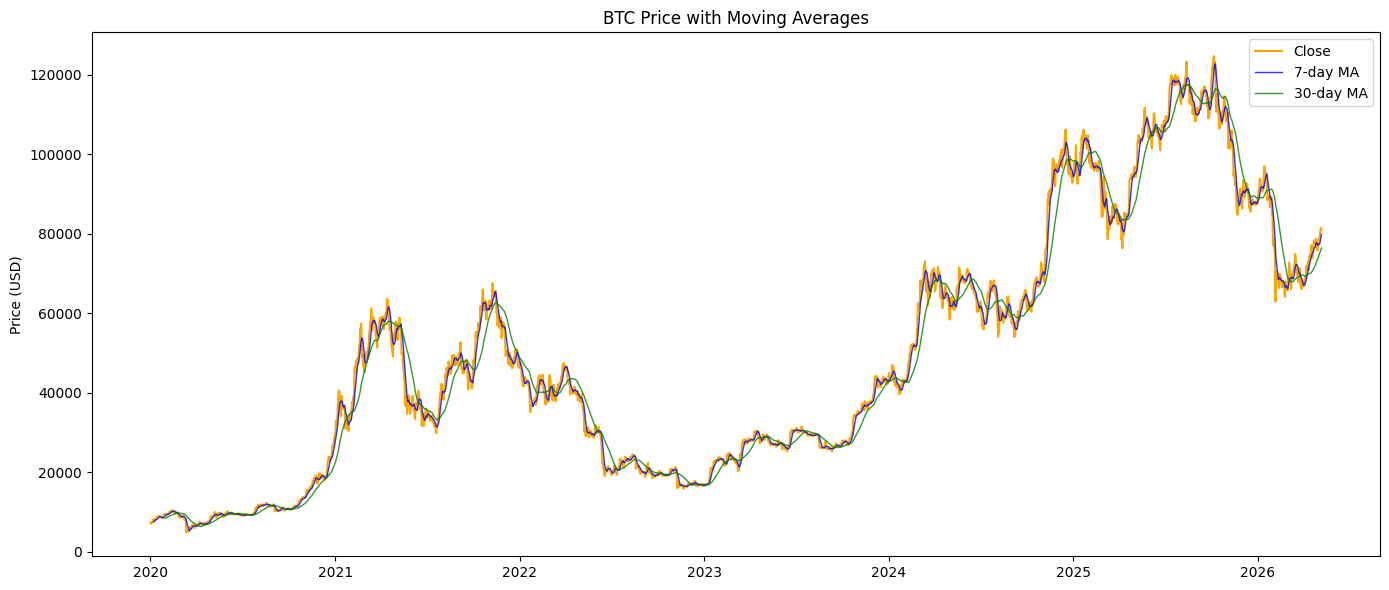

In [21]:
# Moving averages of close price
for window in [7, 14, 30]:
    df[f"close_ma_{window}"] = df["close"].rolling(window=window).mean()

# Visualize against price
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["close"], color="orange", linewidth=1.5, label="Close")
ax.plot(df.index, df["close_ma_7"], color="blue", linewidth=1, label="7-day MA", alpha=0.8)
ax.plot(df.index, df["close_ma_30"], color="green", linewidth=1, label="30-day MA", alpha=0.8)
ax.set_title("BTC Price with Moving Averages")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

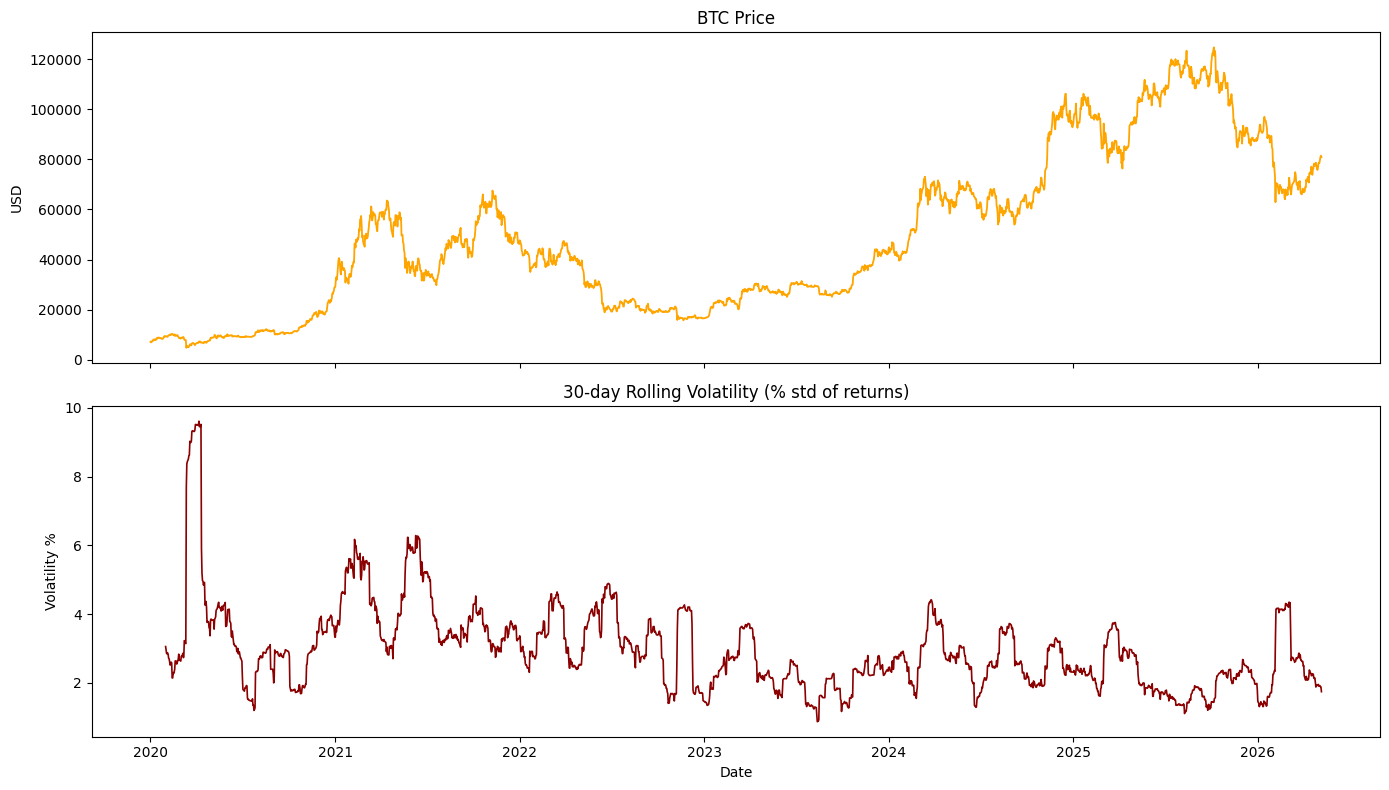

In [ ]:
# Rolling volatility aka std of return
for window in [7, 14, 30]:
    df[f"volatility_{window}"] = df["return_1d"].rolling(window=window).std()

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df["close"], color="orange", linewidth=1.3)
axes[0].set_title("BTC Price")
axes[0].set_ylabel("USD")

axes[1].plot(df.index, df["volatility_30"] * 100, color="darkred", linewidth=1.2)
axes[1].set_title("30-day Rolling Volatility (% std of returns)")
axes[1].set_ylabel("Volatility %")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [24]:
# Rolling stats for sentiment and on-chain
for window in [7, 14]:
    df[f"fear_greed_ma_{window}"] = df["fear_greed"].rolling(window=window).mean()
    df[f"volume_ma_{window}"] = df["volume"].rolling(window=window).mean()
    df[f"hash_rate_ma_{window}"] = df["hash_rate"].rolling(window=window).mean()

df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,close_ma_30,volatility_7,volatility_14,volatility_30,fear_greed_ma_7,volume_ma_7,hash_rate_ma_7,fear_greed_ma_14,volume_ma_14,hash_rate_ma_14
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,74848.543667,0.014141,0.014113,0.019097,35.285714,12687.361234,9.471947e+08,35.000000,13124.974038,9.333929e+08
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,75267.230000,0.013256,0.012979,0.019200,34.285714,14115.366544,9.544825e+08,35.785714,13771.370539,9.408884e+08
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,75662.941333,0.010849,0.013202,0.018885,36.714286,14649.145990,9.617481e+08,37.000000,13916.699726,9.464471e+08


In [28]:
df

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,fear_greed_ma_14,volume_ma_14,hash_rate_ma_14,rsi_14,macd,macd_signal,macd_diff,bb_upper,bb_lower,bb_width
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,7195.24,7255.00,7175.15,7200.85,16792.388165,37.0,1.127185e+08,251735.0,6965.71,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,7200.77,7212.50,6924.74,6965.71,31951.483932,39.0,9.671772e+07,295567.0,7344.96,7200.85,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,6965.49,7405.00,6871.04,7344.96,68428.500451,38.0,1.159241e+08,316517.0,7354.11,6965.71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-04,7345.00,7404.00,7272.21,7354.11,29987.974977,38.0,1.152381e+08,287215.0,7358.75,7344.96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-05,7354.19,7495.00,7318.00,7358.75,38331.085604,39.0,1.118084e+08,287779.0,7758.00,7354.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,35.000000,13124.974038,9.333929e+08,61.720753,1599.953041,1671.746326,-71.793285,79687.687136,73744.422864,0.075644
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,35.785714,13771.370539,9.408884e+08,65.205883,1690.153532,1675.427767,14.725765,80026.522974,73978.533026,0.075731
2026-05-05,79861.01,81791.48,79808.72,80905.52,16947.179950,50.0,9.877829e+08,585611.0,81447.01,79861.01,...,37.000000,13916.699726,9.464471e+08,67.760527,1824.885159,1705.319246,119.565913,80602.485144,74012.123856,0.081457


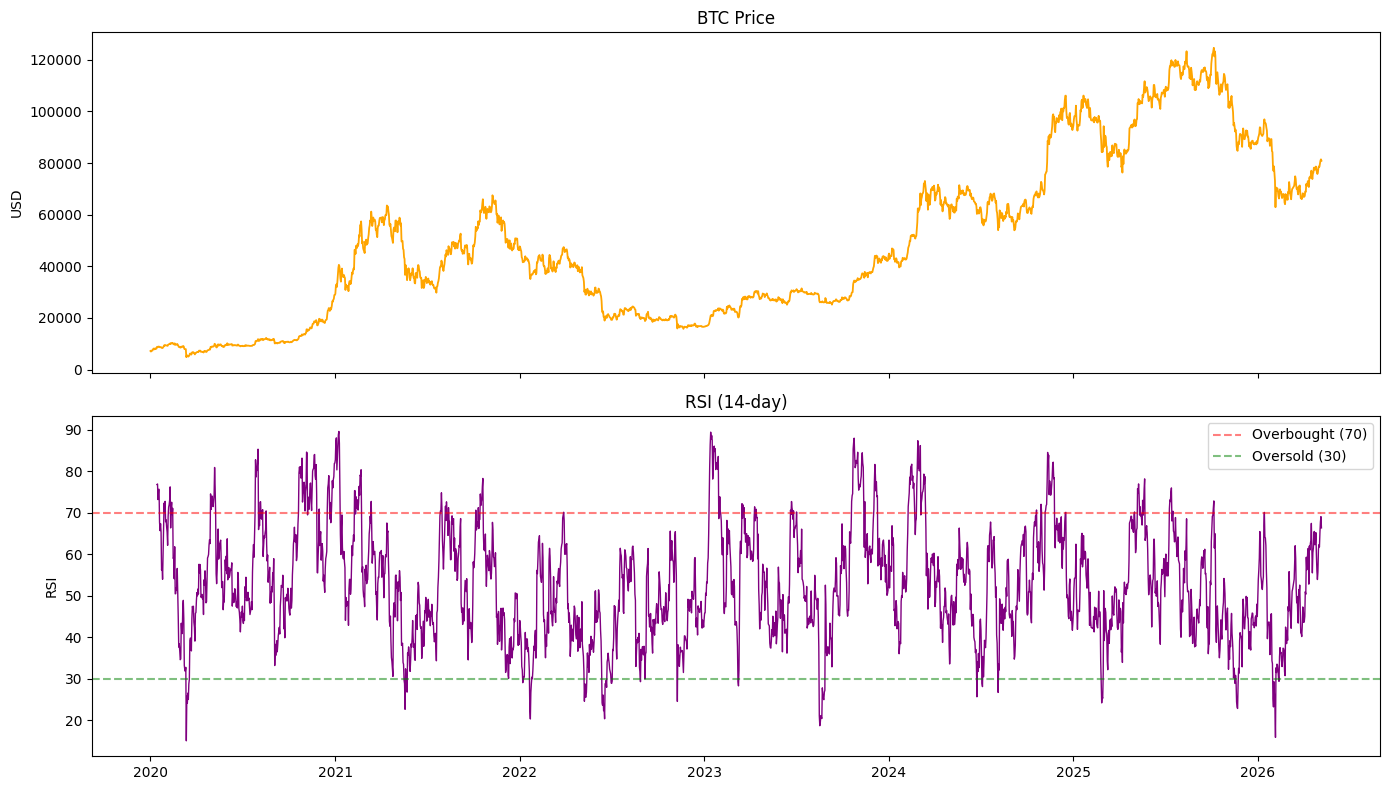

In [31]:
# RSI (Relative Strength Index) - momentum indicator (0–100)
df["rsi_14"] = RSIIndicator(close=df["close"], window=14).rsi()

# Moving Average Convergence Divergence trend indicator
macd = MACD(close=df["close"])
df["macd"] = macd.macd()
df["macd_signal"] = macd.macd_signal()
df["macd_diff"] = macd.macd_diff()

# Bollinger Bands - volatility envelope
bb = BollingerBands(close=df["close"], window=20, window_dev=2)
df["bb_upper"] = bb.bollinger_hband()
df["bb_lower"] = bb.bollinger_lband()
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / df["close"]

# Visualization of RSI
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(df.index, df["close"], color="orange", linewidth=1.3)
axes[0].set_title("BTC Price")
axes[0].set_ylabel("USD")

axes[1].plot(df.index, df["rsi_14"], color="purple", linewidth=1)
axes[1].axhline(70, color="red", linestyle="--", alpha=0.5, label="Overbought (70)")
axes[1].axhline(30, color="green", linestyle="--", alpha=0.5, label="Oversold (30)")
axes[1].set_title("RSI (14-day)")
axes[1].set_ylabel("RSI")
axes[1].legend()
plt.tight_layout()
plt.show()

In [33]:
df["day_of_week"] = df.index.dayofweek      
df["day_of_month"] = df.index.day            
df["month"] = df.index.month                 
df["quarter"] = df.index.quarter             
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df[["day_of_week", "month", "is_weekend"]].head()

,day_of_week,month,is_weekend
date,,,
2020-01-01,2,1,0
2020-01-02,3,1,0
2020-01-03,4,1,0
2020-01-04,5,1,1
2020-01-05,6,1,1


In [34]:
# Cyclical encoding for day of week
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Cyclical encoding for month
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

print("Sample of cyclical features:")
df[["day_of_week", "dow_sin", "dow_cos", "month", "month_sin", "month_cos"]].head(10)

Sample of cyclical features:


,day_of_week,dow_sin,dow_cos,month,month_sin,month_cos
date,,,,,,
2020-01-01,2,0.974928,-0.222521,1,0.5,0.866025
2020-01-02,3,0.433884,-0.900969,1,0.5,0.866025
2020-01-03,4,-0.433884,-0.900969,1,0.5,0.866025
2020-01-04,5,-0.974928,-0.222521,1,0.5,0.866025
2020-01-05,6,-0.781831,0.623490,1,0.5,0.866025
2020-01-06,0,0.000000,1.000000,1,0.5,0.866025
2020-01-07,1,0.781831,0.623490,1,0.5,0.866025
2020-01-08,2,0.974928,-0.222521,1,0.5,0.866025
2020-01-09,3,0.433884,-0.900969,1,0.5,0.866025


In [ ]:
# Data cleaning
df_features = df.dropna()
df_features

,open,high,low,close,volume,fear_greed,hash_rate,n_transactions,target,close_lag_1,...,bb_width,day_of_week,day_of_month,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2020-02-03,9331.59,9618.79,9234.00,9292.24,50892.133451,59.0,1.137859e+08,331012.0,9197.02,9331.51,...,0.155379,0,3,2,1,0,0.000000,1.000000,0.866025,0.500000
2020-02-04,9291.35,9350.00,9093.01,9197.02,53308.175266,56.0,1.014848e+08,309190.0,9612.04,9292.24,...,0.158795,1,4,2,1,0,0.781831,0.623490,0.866025,0.500000
2020-02-05,9197.02,9744.45,9177.22,9612.04,64870.415615,53.0,1.222430e+08,368604.0,9772.00,9197.02,...,0.162046,2,5,2,1,0,0.974928,-0.222521,0.866025,0.500000
2020-02-06,9612.03,9862.57,9526.35,9772.00,64949.706588,61.0,1.037912e+08,315370.0,9813.73,9612.04,...,0.173993,3,6,2,1,0,0.433884,-0.900969,0.866025,0.500000
2020-02-07,9772.00,9885.00,9730.00,9813.73,43966.114632,56.0,1.068665e+08,334938.0,9895.05,9772.00,...,0.186383,4,7,2,1,0,-0.433884,-0.900969,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-02,78231.13,79199.48,78040.00,78686.85,6150.876420,39.0,8.976079e+08,526246.0,78568.57,78231.13,...,0.076371,5,2,5,2,1,-0.974928,-0.222521,0.500000,-0.866025
2026-05-03,78686.84,79447.00,78084.08,78568.57,7425.792900,47.0,1.000953e+09,604132.0,79861.01,78686.85,...,0.075644,6,3,5,2,1,-0.781831,0.623490,0.500000,-0.866025
2026-05-04,78568.58,80776.99,78202.00,79861.01,26042.961350,40.0,9.811977e+08,567996.0,80905.52,78568.57,...,0.075731,0,4,5,2,0,0.000000,1.000000,0.500000,-0.866025


In [48]:
# Save features data
df_features.to_csv("../data/processed/features_dataset.csv")